#Steam Game Success Analytics


## 1. Project Methodology (CRISP-DM)

####Project Methodology
######-This project follows the CRISP-DM (Cross-Industry Standard Process for Data Mining) framework, a widely adopted methodology for data science and analytics projects. CRISP-DM provides a structured approach consisting of six phases: Business Understanding, Data Understanding, Data Preparation, Modeling, Evaluation, and Deployment. Following this framework ensures that the project progresses systematically from defining the problem to delivering actionable insights and predictive models.



##2. Business Understanding

###2.1 Problem Definition

#####The video game industry has become highly competitive, with thousands of new games released on Steam every year. While some games achieve outstanding commercial and player success, many others fail to gain significant attention. Understanding the factors that contribute to a game's success is valuable for developers, publishers, and investors when making strategic decisions.

#####This project aims to analyze Steam game dataset to identify the characteristics associated with successful games. Using features such as genre, release date, estimated owners, peak concurrent players (Peak CCU), review scores, and other available attributes, the project seeks to discover patterns that distinguish highly successful games from less successful ones.

#####The insights gained from this analysis can help stakeholders better understand market trends and support data-driven decision-making in game development and publishing.


###2.2 Business Questions

#####1- What are the key factors that influence the success of a game on Steam?
#####2-What characteristics are commonly shared by successful Steam games?
#####3-Does a game's price have a significant impact on its success?
#####4-Can a machine learning model accurately predict whether a Steam game will be successful based on its features?
#####5-What percentage of Steam games support Windows, Mac, and Linux?
#####6-Does positive review percentage affect success?


##3. Data Understanding

###2.1 Data Source
#####The dataset used in this project was obtained from Kaggle and contains comprehensive information about games available on the Steam platform. It includes various attributes that describe each game, such as its name, release date, genre, price, estimated number of owners, peak concurrent players (Peak CCU), user reviews, playtime, and other relevant features.
##### Kaggle: https://www.kaggle.com/datasets/artermiloff/steam-games-dataset


###2.2 Data Overview

####Import Libraries

In [43]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_style("whitegrid")

####Dataset Loading

In [22]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [3]:
df = pd.read_csv("drive/MyDrive/games_march2025_cleaned.csv")

####Dataset First View

In [4]:
df.head()

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517
4,359550,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,3.99,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,682,2434,306,80,89916,"{'FPS': 9831, 'PvP': 9162, 'e-sports': 9072, '...",84,1168020,76,12608


####Dataset Rows & Columns count

In [5]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 89618
Number of Columns: 47


####Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89618 entries, 0 to 89617
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   appid                     89618 non-null  int64  
 1   name                      89618 non-null  object 
 2   release_date              89618 non-null  object 
 3   required_age              89618 non-null  int64  
 4   price                     89618 non-null  float64
 5   dlc_count                 89618 non-null  int64  
 6   detailed_description      89421 non-null  object 
 7   about_the_game            89398 non-null  object 
 8   short_description         89498 non-null  object 
 9   reviews                   10401 non-null  object 
 10  header_image              89618 non-null  object 
 11  website                   41114 non-null  object 
 12  support_url               44110 non-null  object 
 13  support_email             78798 non-null  object 
 14  window

####Duplicate Values

In [8]:
print("Total Number of duplicate values :", df.duplicated().sum())

Total Number of duplicate values : 0


####Missing Values/Null Values

In [9]:
print("Total Number of null values : ", df.isnull().sum())

Total Number of null values :  appid                           0
name                            0
release_date                    0
required_age                    0
price                           0
dlc_count                       0
detailed_description          197
about_the_game                220
short_description             120
reviews                     79217
header_image                    0
website                     48504
support_url                 45508
support_email               10820
windows                         0
mac                             0
linux                           0
metacritic_score                0
metacritic_url              86071
achievements                    0
recommendations                 0
notes                       72975
supported_languages             0
full_audio_languages            0
packages                        0
developers                      0
publishers                      0
categories                      0
genres           

####Variables Description

In [ ]:
df.describe()

,appid,required_age,price,dlc_count,metacritic_score,achievements,recommendations,user_score,score_rank,positive,...,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
count,8.961800e+04,89618.000000,89618.000000,89618.000000,89618.000000,89618.000000,8.961800e+04,89618.000000,39.000000,8.961800e+04,...,8.961800e+04,89618.000000,8.961800e+04,89618.000000,89618.000000,8.961800e+04,89618.000000,8.961800e+04,89618.000000,89618.000000
mean,1.656904e+06,0.183624,7.309623,0.595583,2.903245,20.552333,1.009401e+03,0.032817,99.128205,1.269896e+03,...,1.149119e+02,5.032694,1.147559e+02,5.301814,4.558627,9.833994e+01,45.352418,1.315490e+03,5.231639,15.584581
std,9.168390e+05,1.725594,13.331073,15.351920,14.445358,163.562418,2.204815e+04,1.615149,0.695076,3.181441e+04,...,6.814748e+03,181.100334,8.806711e+03,189.591095,16.538036,5.717544e+03,40.685695,3.542370e+04,22.335358,444.277307
min,2.000000e+01,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,98.000000,0.000000e+00,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,-1.000000,-1.000000e+00,-1.000000,-1.000000
25%,8.550525e+05,0.000000,0.990000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,99.000000,1.000000e+00,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,-1.000000,-1.000000e+00,-1.000000,-1.000000
50%,1.524730e+06,0.000000,4.990000,0.000000,0.000000,5.000000,0.000000e+00,0.000000,99.000000,1.000000e+01,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,60.000000,1.500000e+01,-1.000000,-1.000000
75%,2.430852e+06,0.000000,9.990000,0.000000,0.000000,20.000000,0.000000e+00,0.000000,100.000000,5.800000e+01,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,84.000000,8.100000e+01,-1.000000,-1.000000
max,3.542350e+06,21.000000,999.980000,3427.000000,97.000000,9821.000000,4.401572e+06,100.000000,100.000000,7.480813e+06,...,1.462997e+06,18568.000000,1.462997e+06,18568.000000,100.000000,1.212356e+06,100.000000,8.632939e+06,100.000000,96473.000000


#####**Game Information**: name, release_date, genres, categories, developers, publishers
##### **Commercial Features**: price, discount, estimated_owners, packages
##### **Player Engagement**: peak_ccu, average_playtime_forever, median_playtime_forever, etc
###### **User Feedback**: positive, negative, pct_pos_total, num_reviews_total, metacritic_score
##### **Platform Support**: windows, mac, linux
##### **Text & Media Features**: about_the_game, detailed_description, screenshots, movies, header_image, etc

##4. Data Cleaning and Preparation

###4.1 Handling Missing Values

In [30]:
missing_values = df.isnull().sum()

missing_percentage = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage
})
missing_df = missing_df[missing_df["Missing Values"] > 0]

missing_df.sort_values(by="Percentage (%)", ascending=False)

,Missing Values,Percentage (%)


#####To assess data quality, the percentage of missing values was calculated for each feature. As part of the data cleaning strategy adopted in this project, any feature with more than 20% missing values was considered unsuitable for analysis and was removed from the dataset.

In [31]:
df = df.drop(columns=["score_rank", "metacritic_url", "reviews", "notes", "website", "support_url", "support_email"])

KeyError: "['score_rank', 'metacritic_url', 'reviews', 'notes', 'website', 'support_url', 'support_email'] not found in axis"

###4.2 Handling Duplicate Records

In [ ]:
print("Total Number of duplicate values :", df.duplicated().sum())

#####The analysis showed that the dataset contained no duplicate records. Therefore, no duplicate rows were removed.

###4.3 Removing Irrelevant Features

#####- Several features were removed during the data preparation stage because they were not relevant to the objectives of this project. These features mainly contained URLs, multimedia links, or lengthy textual descriptions that were not used in the exploratory data analysis or machine learning model.
#####- The user_score feature was removed because it contained almost exclusively zero values, providing insufficient variation for meaningful analysis or predictive modeling.

In [32]:
df["user_score"].value_counts()

KeyError: 'user_score'

In [ ]:
df = df.drop(columns =["detailed_description", "about_the_game", "short_description", "header_image", "packages", "screenshots", "movies", "user_score", "tags"])

###4.4 Data Type Conversion

#####The release_date feature was converted from a text format to a datetime data type to enable proper handling of date-related information. In addition, boolean features representing operating system support (windows, mac, and linux) were converted into binary numerical values (0 and 1), making them suitable for statistical analysis and predictive modeling.

In [33]:
df["release_date"] = pd.to_datetime(df["release_date"])

In [34]:
df["release_year"] = df["release_date"].dt.year

In [35]:
bool_cols = ["windows", "mac", "linux"]
df[bool_cols] = df[bool_cols].astype(int)

###4.5 Feature Engineering

####4.5.1 Creating estimated_owners_numeric & estimated_game_sales

#####Feature engineering was performed to transform existing data into a format that is more suitable for analysis and machine learning. This process helps improve the usability of the dataset by creating meaningful numerical features from the original data. The estimated_owners feature was originally stored as a range (e.g., "20,000 - 50,000"), making it unsuitable for numerical analysis. To address this, a new feature named estimated_owners_numeric was created by calculating the midpoint of each ownership range.

In [36]:
df['estimated_owners_numeric'] = df['estimated_owners'].apply( lambda x: sum(map(int, x.replace(',', '').split('-'))) / 2)

#####An additional feature, estimated_game_sales, was created by multiplying the (price ,estimated_owners_numeric). Since the dataset does not provide actual revenue figures, this feature serves as an approximation of the game's potential revenue rather than its actual earnings.

In [37]:
df["estimated_game_sales"] = df["price"] * df["estimated_owners_numeric"]

####4.5.2 Target Variable Engineering

#####One of the most important stages of this project was defining an appropriate target variable. The original Steam dataset did not include a single feature that directly represented the overall success of a game. Therefore, a new target variable, named **Success**, was engineered to provide a comprehensive measure of game success.

#####Instead of relying on a single metric, the Success was designed to capture multiple dimensions. This approach was chosen because game success cannot be accurately represented by only one indicator. For example, a game may have a large number of owners but low player engagement. Considering multiple dimensions provides a more balanced and realistic evaluation of a game's overall success.

#####The Success was constructed using the following three dimensions:

#####**Engagement Success (60%)** – Represents how actively players engage with the game. This dimension combines:

#####**Peak Concurrent Users (Peak CCU):** Measures the highest number of simultaneous players, reflecting the game's popularity.
#####**Median Playtime Forever:** Measures the typical amount of time players spend playing the game, indicating long-term engagement.

#####**Commercial Success (40%)** – Represented by **Estimated Owners Numeric**, which reflects the game's market reach and commercial performance based on the estimated number of owners.

#####Since these features have different scales and distributions, directly combining their raw values could cause certain features to dominate the final score. To overcome this issue, each feature was converted into its **percentile rank** using the `rank(pct=True)` method. This transformation scales all features to a common range between 0 and 1 based on their relative ranking within the dataset, allowing each metric to contribute fairly to the final Success while reducing the influence of extreme values.

#####The final Success was calculated using the following weighted formula:

#####**60%** – Engagement Success
#####**40%** – Commercial Success

#####The weighting scheme was designed to place greater emphasis on player engagement, as sustained player activity is considered a strong indicator of a game's long-term success. Commercial performance was also assigned a substantial weight to reflect the game's market reach.

#####The resulting **Success** provides a comprehensive measure of game success by combining popularity, player engagemen and commercial performance into a single continuous metric that is used throughout the subsequent analysis.


In [55]:
engagement = (df["median_playtime_forever"].rank(pct=True) +df["peak_ccu"].rank(pct=True)) / 2
Commercial = df["estimated_owners_numeric"].rank(pct=True)

df['success'] = (0.6 * engagement + 0.4 * Commercial)

####Download File

In [39]:
df.to_csv("steam_cleaned.csv", index=False)

In [44]:
from google.colab import files

files.download("steam_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##5.  Exploratory Data Analysis (EDA)

###5.1 Univariate Analysis

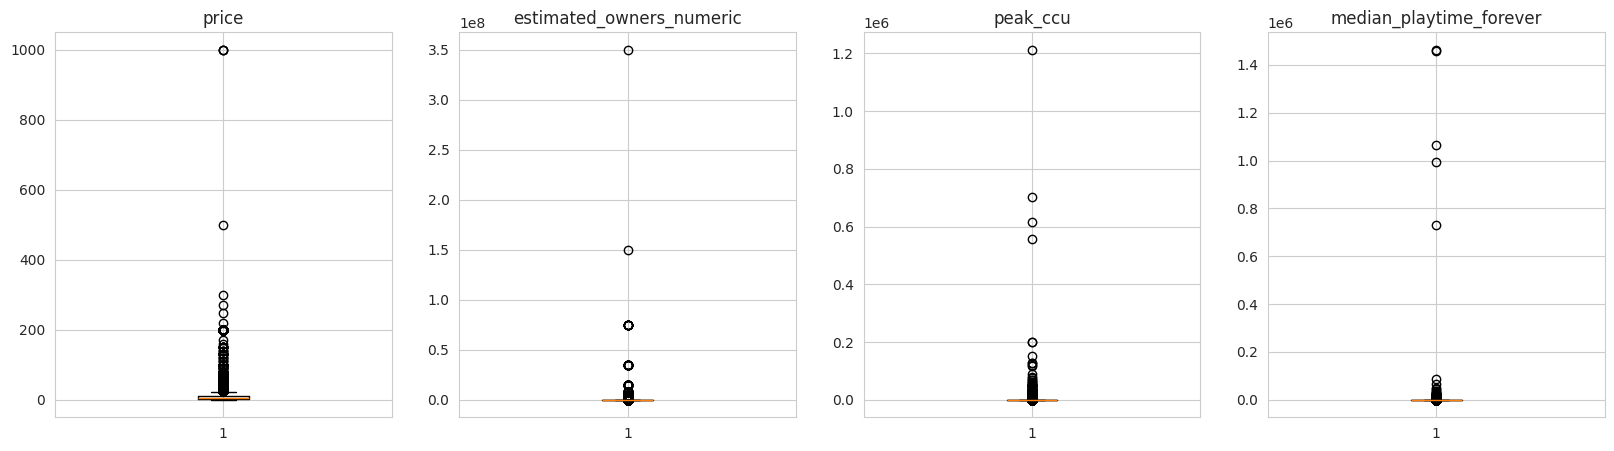

In [ ]:
columns = [
    "price",
    "estimated_owners_numeric",
    "peak_ccu",
    "median_playtime_forever"
]

n_cols = 4
n_rows = math.ceil(len(columns) / n_cols)

plt.figure(figsize=(5 * n_cols, 5 * n_rows))

for i, col in enumerate(columns, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.boxplot(df[col].dropna())
    plt.title(col)

plt.show()

####several numerical features contain extreme outliers, these observations were not removed because they represent real and valid characteristics of highly successful Steam games rather than data entry errors. Retaining these values preserves the integrity of the dataset and ensures that exceptional games are included in the analysis.

#####-The distribution of Price contains a large number of upper outliers. Most Steam games are sold at relatively low prices, while a small number of games and software products have exceptionally high prices. And  most notably **The Leverage Game Business Edition**. they were retained.

#####-The distribution of Estimated Owners Numeric is highly right-skewed and contains several extreme outliers. These observations correspond to exceptionally popular games with significantly larger player bases. And most notably game **Dot 2, Counter-Strike 2 and PUBG: BATTLEGROUNDS**. Since these values accurately reflect real-world market performance, they were retained.

#####- The distribution of Peak CCU revealed several extreme outliers, most notably **Counter-Strike 2**. These values were retained because they represent genuine observations rather than data errors, reflecting the exceptional popularity of certain games on Steam. they were retained.

#####- The Median Playtime Forever feature contains several upper outliers, indicating that players spend exceptionally long periods playing a small number of games. These values reflect genuine player engagement rather than anomalies and were therefore retained.

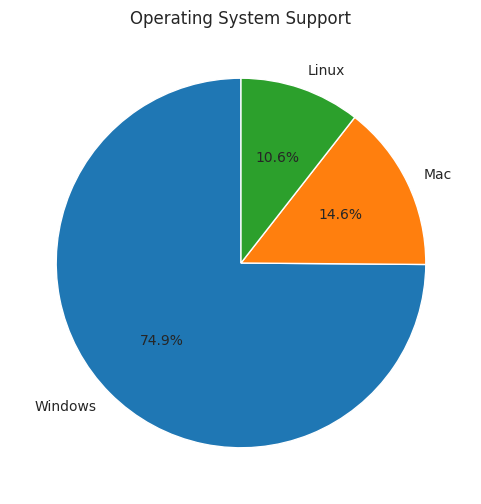

In [ ]:
os_support = {
    "Windows": df["windows"].sum(),
    "Mac": df["mac"].sum(),
    "Linux": df["linux"].sum()
}

plt.figure(figsize=(6,6))

plt.pie(
    os_support.values(),
    labels=os_support.keys(),
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Operating System Support")
plt.show()

#####-The analysis reveals that Windows is the dominant operating system supported by Steam games, followed by Mac, while Linux has the lowest support among the three platforms. This indicates that developers primarily focus on Windows compatibility due to its larger gaming user base.

###5.2 Bivariate Analysis

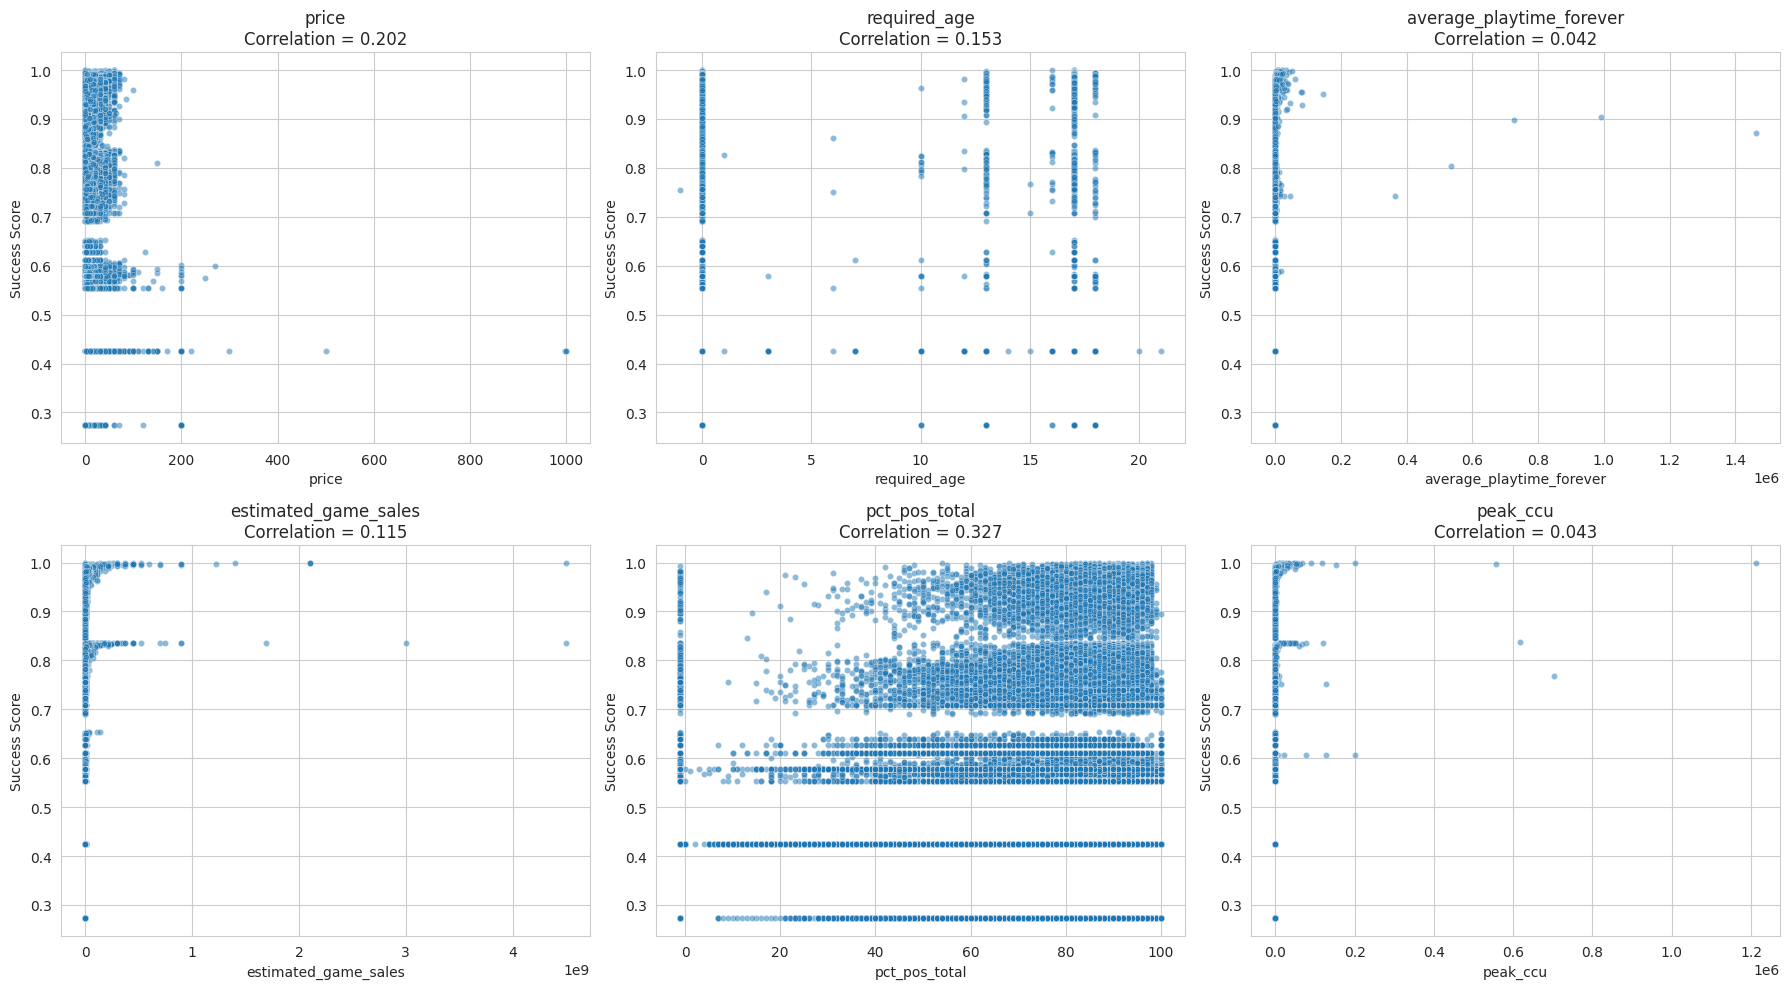

In [62]:
features = [
    "price",
    "required_age",
    "average_playtime_forever",
    "estimated_game_sales",
    "pct_pos_total",
    "peak_ccu"
]

n_cols = 3
n_rows = math.ceil(len(features) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, feature in enumerate(features, 1):

    plt.subplot(n_rows, n_cols, i)

    sns.scatterplot(
        data=df,
        x=feature,
        y="success",
        alpha=0.5,
        s=20
    )

    # Correlation
    corr = df[[feature, "success"]].corr().iloc[0, 1]

    plt.title(f"{feature}\nCorrelation = {corr:.3f}")
    plt.xlabel(feature)
    plt.ylabel("Success Score")

plt.tight_layout()
plt.show()

#####-Among the analyzed features, positive review percentage (**pct_pos_total**) has the strongest relationship with the Success Score (r = 0.327), suggesting that player satisfaction contributes more to game success than price, age rating, playtime, sales, or peak concurrent users. However, all correlations are relatively weak (below 0.4), indicating that game success is influenced by multiple factors rather than a single feature.

/tmp/ipykernel_9934/1079340564.py:32: UserWarning: Glyph 39740 (\N{CJK UNIFIED IDEOGRAPH-9B3C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9934/1079340564.py:32: UserWarning: Glyph 35895 (\N{CJK UNIFIED IDEOGRAPH-8C37}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9934/1079340564.py:32: UserWarning: Glyph 24037 (\N{CJK UNIFIED IDEOGRAPH-5DE5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9934/1079340564.py:32: UserWarning: Glyph 20316 (\N{CJK UNIFIED IDEOGRAPH-4F5C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9934/1079340564.py:32: UserWarning: Glyph 23460 (\N{CJK UNIFIED IDEOGRAPH-5BA4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 39740 (\N{CJK UNIFIED IDEOGRAPH-9B3C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages

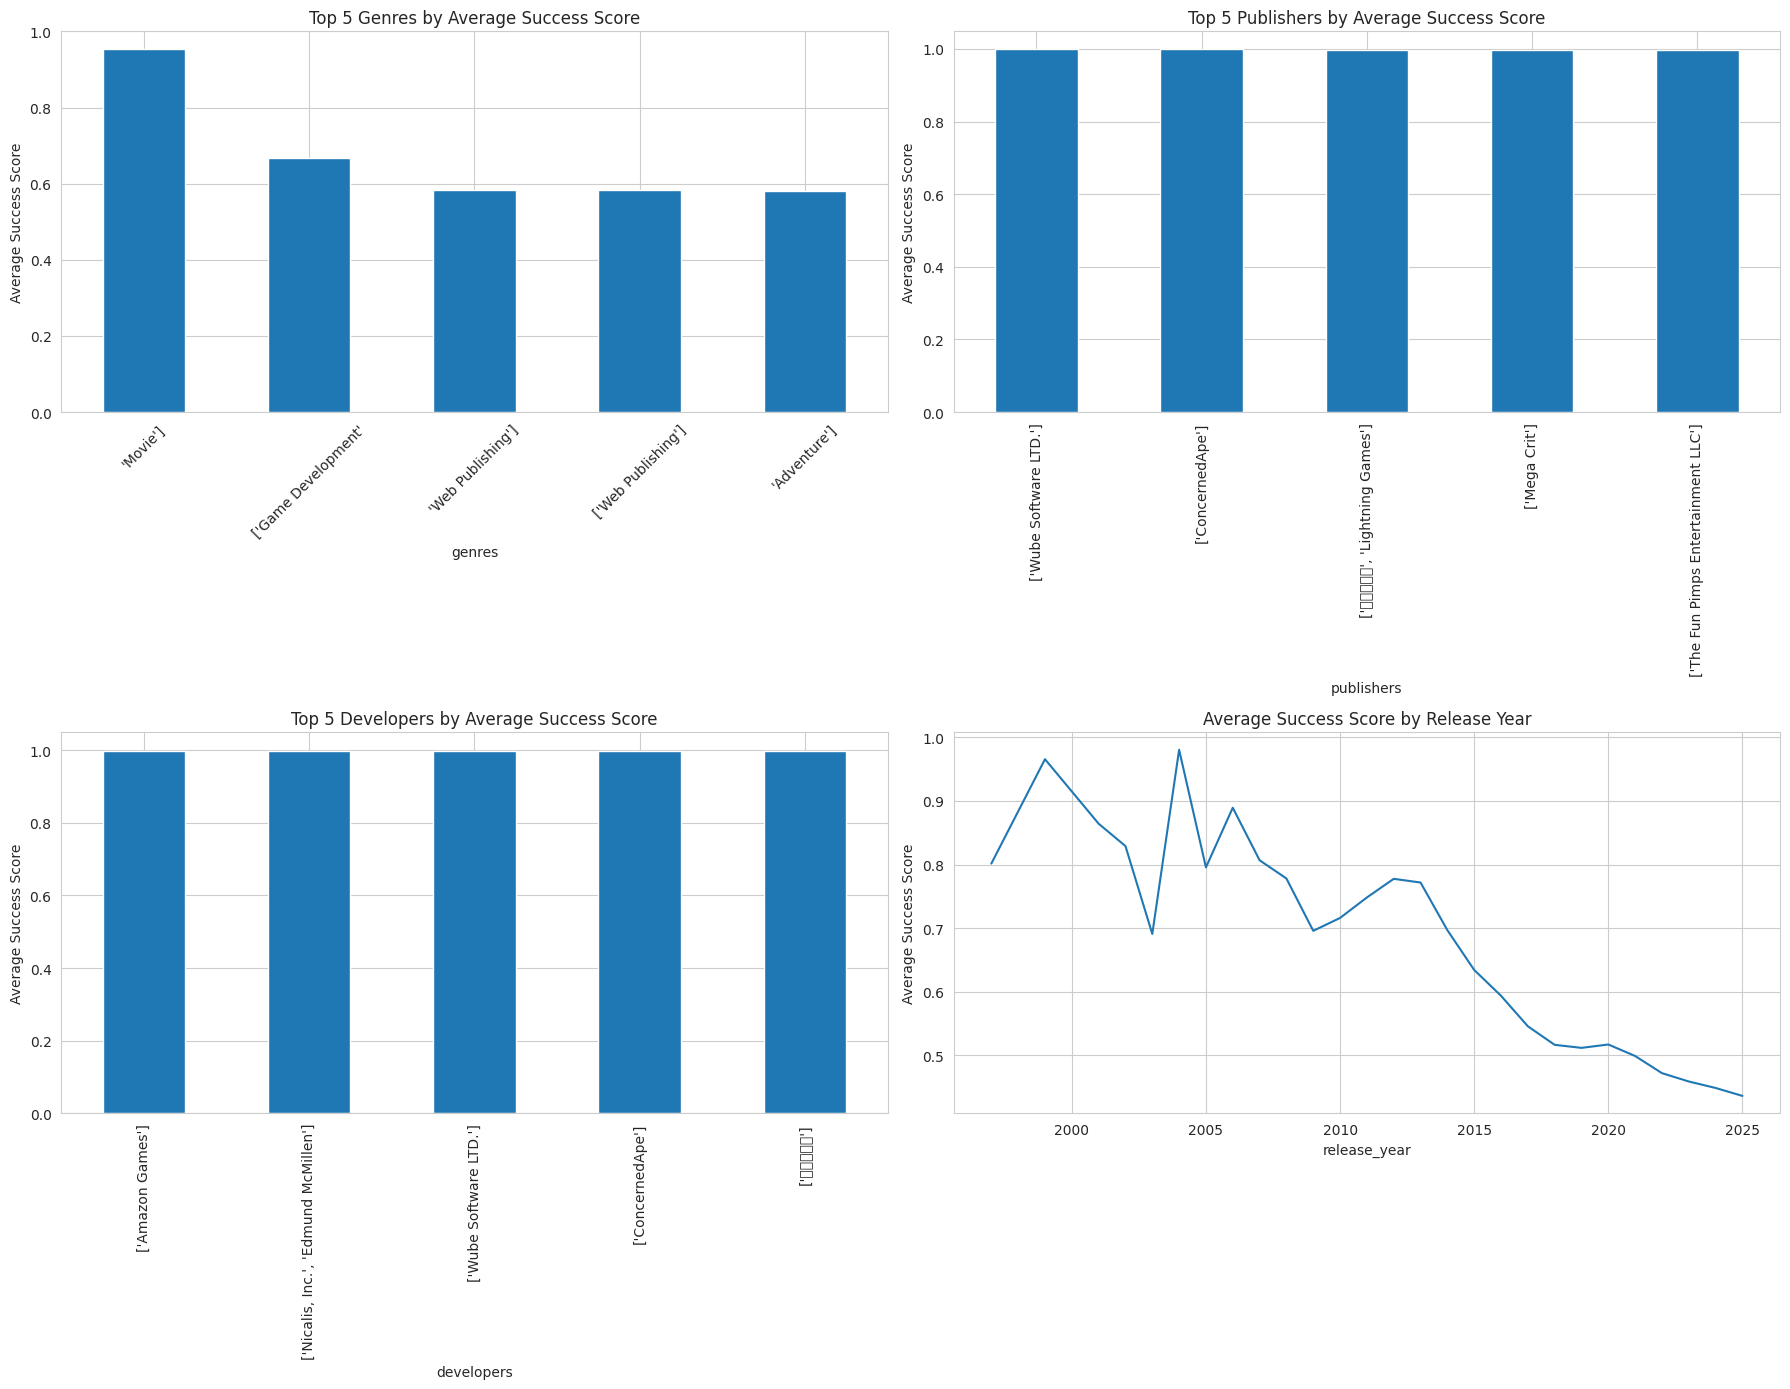

In [59]:
genre_df = df.copy()
genre_df["genres"] = genre_df["genres"].str.split(",")
genre_df = genre_df.explode("genres")
genre_df["genres"] = genre_df["genres"].str.strip()

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Average Success Score by Genre
(genre_df.groupby("genres")["success"] .mean().sort_values(ascending=False).head()).plot(kind="bar", ax=axes[0,0])
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].set_title("Top 5 Genres by Average Success Score")
axes[0,0].set_ylabel("Average Success Score")

# 2. Top Publishers
(df.groupby("publishers")["success"].mean().sort_values(ascending=False).head()).plot(kind="bar", ax=axes[0,1])
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,1].set_title("Top 5 Publishers by Average Success Score")
axes[0,1].set_ylabel("Average Success Score")

# 3. Top Developers
(df.groupby("developers")["success"].mean().sort_values(ascending=False).head()).plot(kind="bar", ax=axes[1,0])
axes[0,0].tick_params(axis='x', rotation=45)
axes[1,0].set_title("Top 5 Developers by Average Success Score")
axes[1,0].set_ylabel("Average Success Score")

# 4. Average Success Score by Release Year
(df.groupby("release_year")["success"] .mean()).plot(ax=axes[1,1])
axes[0,0].tick_params(axis='x', rotation=45)
axes[1,1].set_title("Average Success Score by Release Year")
axes[1,1].set_ylabel("Average Success Score")

plt.tight_layout()
plt.show()

In [71]:
developer_stats = df.groupby('developers').agg(
    avg_success=('success', 'mean'),
    games=('appid', 'count')
)

developer_stats = developer_stats[developer_stats['games'] >= 5]
developer_stats.sort_values('avg_success', ascending=False)

,avg_success,games
developers,,
['Avalanche Studios'],0.975996,5
"['FromSoftware, Inc.']",0.969261,6
['Coffee Stain Studios'],0.967532,5
['DICE'],0.964618,9
['Supergiant Games'],0.947195,5
...,...,...
['Game Hollywood Games'],0.273717,9
['Dirty Adventures 🖤'],0.273717,7
['Catnip Studio'],0.273717,7


In [75]:
df.groupby('genres')['success'].mean().sort_values(ascending=False)

,success
genres,
"['Action', 'Adventure', 'Massively Multiplayer', 'Strategy', 'Free To Play']",0.992365
"['Indie', 'Racing', 'Simulation', 'Strategy', 'Early Access']",0.988851
"['Action', 'Adventure', 'Casual', 'Indie', 'Massively Multiplayer', 'Racing', 'Early Access']",0.987430
"['Action', 'Adventure', 'Massively Multiplayer', 'Racing', 'Free To Play']",0.985771
"['Action', 'Massively Multiplayer', 'Racing']",0.982929
...,...
"['Action', 'Adventure', 'Casual', 'Racing', 'Simulation', 'Sports', 'Free To Play']",0.273717
"['Action', 'Adventure', 'Casual', 'Racing', 'Simulation', 'Free To Play']",0.273717
"['Racing', 'Free To Play', 'Early Access']",0.273717


###5.3 Multivairite

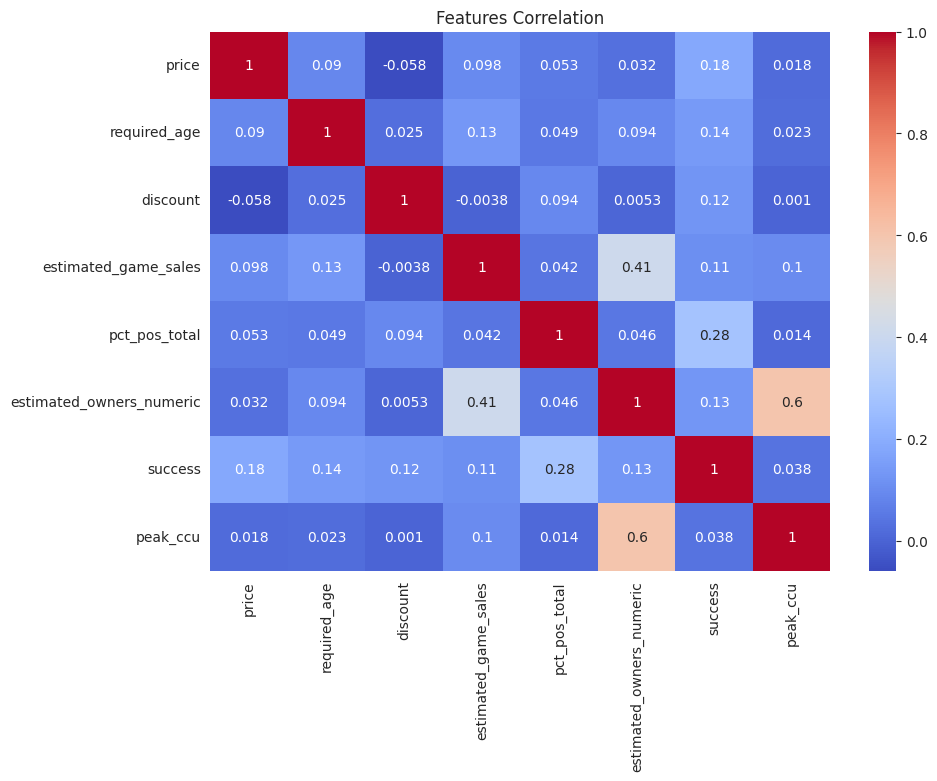

In [50]:
columns = [
  "price",
    "required_age",
    "discount",
    "estimated_game_sales",
    "pct_pos_total",
    "estimated_owners_numeric",
   "success",
  "peak_ccu"
]

corr = df[columns].corr()
plt.figure(figsize=(10,7))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Features Correlation")
plt.show()

#####-Positive review percentage has the strongest relationship with game success among the analyzed features, suggesting that player satisfaction contributes more to success than price or ownership alone.

### 5.4 Insights Summary

#####-Games with higher positive review percentages tend to achieve higher success scores, highlighting the importance of player satisfaction in overall game performance.
#####-Price alone does not determine success; many low-priced and free-to-play games outperform more expensive titles, suggesting that gameplay quality and player experience have a greater impact than cost.
#####-A small number of blockbuster games dominate the market, with exceptionally high ownership and player activity compared to the majority of Steam games.
#####-Most games attract relatively small player communities, while only a few achieve massive popularity, resulting in a highly skewed distribution of player engagement.
#####-Games released in earlier years achieved higher average success scores, while more recent releases show a gradual decline. This may reflect the increasing competition on Steam, where new titles compete in a much more crowded marketplace.
#####-Several developers with relatively small game portfolios achieved very high average success scores, suggesting that consistent quality can be more influential than simply releasing a large number of games.

##6. Modeling

###6.1Linear Regression

In [ ]:
x = df[ [
        "required_age",
        "price",
        "dlc_count",
        "windows",
        "mac",
        "linux",
        "metacritic_score",
        "achievements",
        "recommendations",
        "pct_pos_total",
        "discount",
        "num_reviews_total",
        "pct_pos_recent",
        "num_reviews_recent",
        "estimated_game_sales",
        "median_playtime_forever",
        "peak_ccu",
        "estimated_owners_numeric"
    ]]
y = df["success"]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.2,random_state=42)

In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
model = LinearRegression()
model.fit(x_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(x_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

MAE : 0.1103
RMSE: 0.1649
R²  : 0.2012


###6.2 Support Vector Regression (SVR)

In [ ]:
model = SVR()
model.fit(x_train_scaled, y_train)

In [ ]:
y_pred = model.predict(x_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

MAE : 0.0957
RMSE: 0.1325
R²  : 0.4838


###6.3 Model Comparison

| Model                           |      MAE ↓ |     RMSE ↓ |       R² ↑ |
| ------------------------------- | ---------: | ---------: | ---------: |
| Linear Regression               |     0.1106 |     0.1657 |     0.1929 |
| Support Vector Regression (SVR) | **0.0957** | **0.1325** | **0.4838** |


#####The performance comparison shows that the Support Vector Regression (SVR) model outperformed Linear Regression across all evaluation metrics. SVR achieved lower MAE and RMSE values, indicating more accurate predictions, while its higher R² score demonstrates a better ability to explain the variation in the Success Score. These results suggest that the relationship between the selected features and game success is non-linear, making SVR a more suitable model for this problem.

##7. Evaluation

###7.1 Business Objectives Evaluation

| Business Question                                        | Result                                                                                                                           |
| -------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------- |
| What factors influence game success?                     | Success is influenced by multiple factors, with positive reviews showing the strongest relationship among the analyzed features. |
| Does price affect success?                               | A weak positive relationship was observed between price and success.                                                             |
| Is there a relationship between playtime and success?    | Playtime was incorporated into the Success Score and therefore was not evaluated as an independent predictor.                    |
| What are the common characteristics of successful games? | Successful games generally receive higher player satisfaction and stronger community engagement.                                 |
| Do ratings affect success?                               | Positive review percentage showed the strongest correlation with success among the analyzed variables.                           |


###7.2 Model Performance Evaluation

| Model             |        MAE |       RMSE |         R² |
| ----------------- | ---------: | ---------: | ---------: |
| Linear Regression |     0.1106 |     0.1657 |     0.1929 |
| SVR               | **0.0957** | **0.1325** | **0.4838** |


#####The SVR model outperformed Linear Regression across all evaluation metrics and was therefore selected as the final model.

##8. Deployment

###8.1 Deployment Overview

#####After developing and evaluating the Support Vector Regression (SVR) model, the project was deployed as a web-based application to provide users with an interactive platform for exploring Steam game analytics. The application display data visualization and allowing users to analyze Steam data.

###8.2 System Components

| Component    | Description                                              |
| ------------ | -------------------------------------------------------- |
| HTML         | Creates the structure and layout of the website.         |
| CSS          | Styles the website and improves the user interface.      |
| JavaScript   | Adds interactive navigation and page functionality.      |
| Power BI     | Displays interactive dashboards and data visualizations. |
      |
